In [1]:
import json
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

records = []
for path in glob.glob('results/uniform_*.json'):
    if 'neighbors' in path or 'ground' in path:
        continue
    label = re.search(r'uniform_(.+)\.json', path).group(1)
    with open(path) as f:
        for r in json.load(f)['results']:
            r['label'] = label
            records.append(r)

df = pd.DataFrame(records)
print(df.shape)
df.head()

(180, 16)


,seed,num_threads,beam_width,num_queries,catapults_enabled,bucket_capacity,num_hashes,elapsed_secs,qps,checksum,avg_dists_computed,avg_nodes_visited,searches_with_catapults,catapult_usage_pct,avg_catapults_added,label
0,42,4,1,150000,True,40,8,2.602329,57640.681085,70762566961,116.446967,2.669633,147152.0,98.101333,0.981013,catapult
1,42,4,2,150000,True,40,8,4.256507,35240.163315,71255798228,174.279367,4.674187,146943.0,97.962000,0.979620,catapult
2,42,4,4,150000,True,40,8,6.621634,22653.017820,71850702729,273.689027,8.122647,146771.0,97.847333,0.978473,catapult
3,42,4,8,150000,True,40,8,11.486628,13058.662897,72180585219,447.620553,14.169647,146603.0,97.735333,0.977353,catapult
4,42,4,16,150000,True,40,8,19.440529,7715.839579,72718733790,755.106920,24.899173,146439.0,97.626000,0.976260,catapult


In [2]:
import os

# Average across seeds
agg = df.groupby(['label', 'num_threads', 'beam_width']).agg(
    qps=('qps', 'mean'),
    avg_dists_computed=('avg_dists_computed', 'mean'),
    avg_nodes_visited=('avg_nodes_visited', 'mean'),
    catapult_usage_pct=('catapult_usage_pct', 'mean'),
).reset_index()

threads = sorted(agg['num_threads'].unique())
beam_widths = sorted(agg['beam_width'].unique())
labels = sorted(agg['label'].unique())

colors = {'catapult': '#1f77b4', 'vanilla': '#ff7f0e', 'lshapg': '#2ca02c'}
markers = {'catapult': 'o', 'vanilla': 's', 'lshapg': '^'}

# fallback for any unexpected label
import itertools
_extra_colors = itertools.cycle(['#9467bd', '#8c564b', '#e377c2'])
_extra_markers = itertools.cycle(['D', 'P', 'X'])
for lbl in labels:
    if lbl not in colors:
        colors[lbl] = next(_extra_colors)
        markers[lbl] = next(_extra_markers)

os.makedirs('figures/uniform', exist_ok=True)
print('figures/uniform/ ready')

figures/uniform/ ready


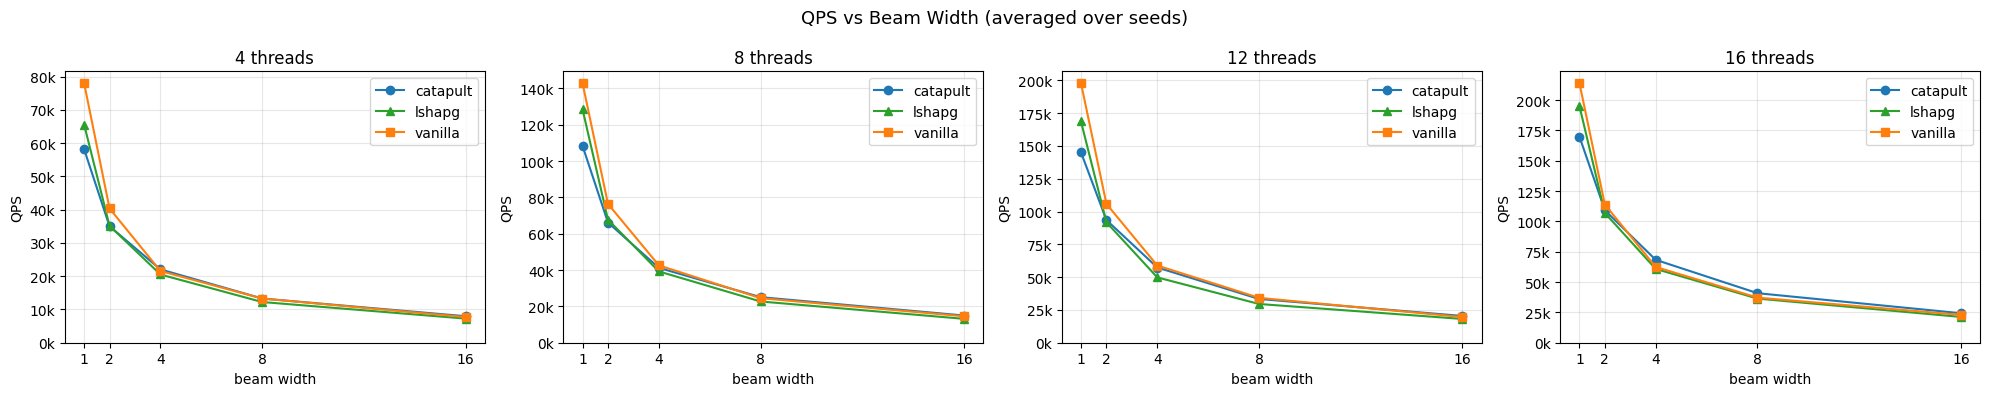

In [3]:
# Plot 1: QPS vs beam_width per num_threads
csv = agg[['label', 'num_threads', 'beam_width', 'qps']]
csv.to_csv('figures/uniform/plot1_qps_vs_beamwidth.csv', index=False)

fig, axes = plt.subplots(1, len(threads), figsize=(5 * len(threads), 4), sharey=False)
for ax, t in zip(axes, threads):
    for lbl in labels:
        sub = agg[(agg['label'] == lbl) & (agg['num_threads'] == t)].sort_values('beam_width')
        ax.plot(sub['beam_width'], sub['qps'], marker=markers[lbl], color=colors[lbl], label=lbl)
    ax.set_title(f'{t} threads')
    ax.set_xlabel('beam width')
    ax.set_ylabel('QPS')
    ax.set_ylim(0, None)
    ax.set_xticks(beam_widths)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle('QPS vs Beam Width (averaged over seeds)', fontsize=13)
plt.tight_layout()
fig.savefig('figures/uniform/plot1_qps_vs_beamwidth.png', dpi=150)
plt.show()

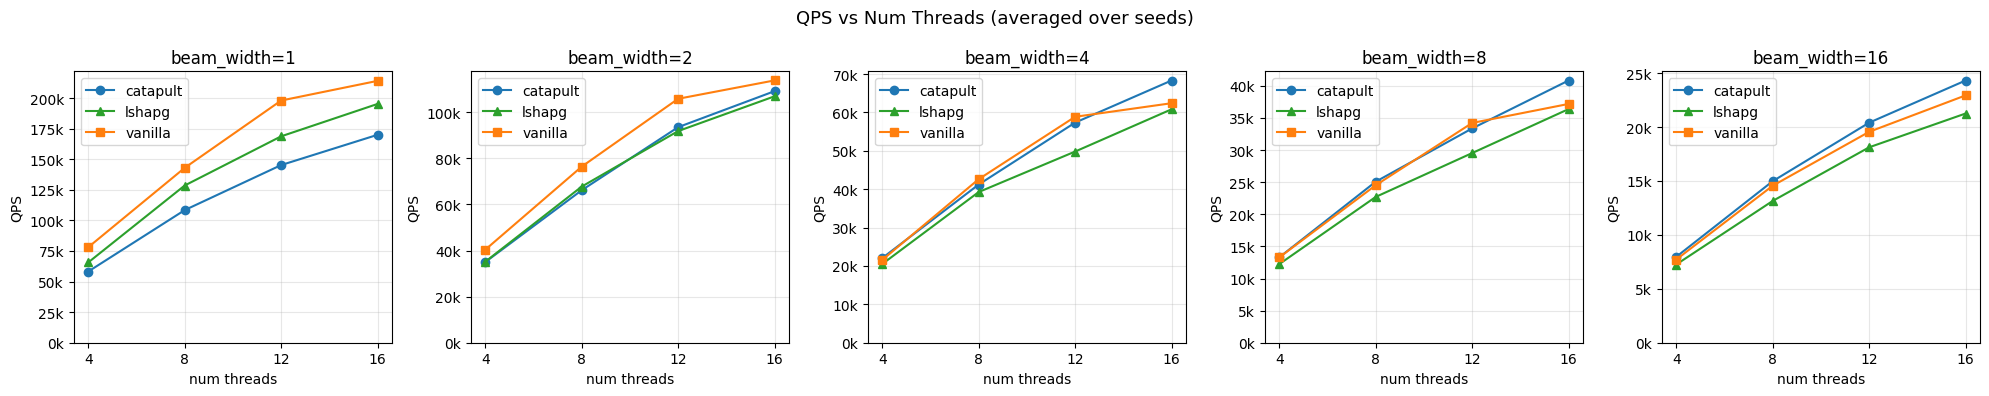

In [4]:
# Plot 2: QPS vs num_threads per beam_width
csv = agg[['label', 'num_threads', 'beam_width', 'qps']]
csv.to_csv('figures/uniform/plot2_qps_vs_threads.csv', index=False)

fig, axes = plt.subplots(1, len(beam_widths), figsize=(4 * len(beam_widths), 4), sharey=False)
for ax, bw in zip(axes, beam_widths):
    for lbl in labels:
        sub = agg[(agg['label'] == lbl) & (agg['beam_width'] == bw)].sort_values('num_threads')
        ax.plot(sub['num_threads'], sub['qps'], marker=markers[lbl], color=colors[lbl], label=lbl)
    ax.set_title(f'beam_width={bw}')
    ax.set_xlabel('num threads')
    ax.set_ylim(0, None)
    ax.set_ylabel('QPS')
    ax.set_xticks(threads)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle('QPS vs Num Threads (averaged over seeds)', fontsize=13)
plt.tight_layout()
fig.savefig('figures/uniform/plot2_qps_vs_threads.png', dpi=150)
plt.show()

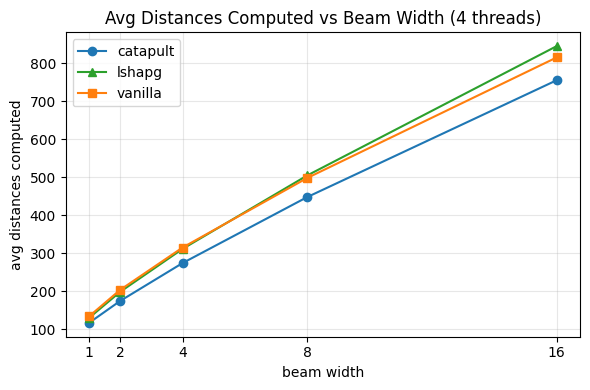

In [5]:
# Plot 3: avg_dists_computed vs beam_width — all variants
csv = agg[['label', 'num_threads', 'beam_width', 'avg_dists_computed']]
csv.to_csv('figures/uniform/plot3_avg_dists.csv', index=False)

t = threads[0]
fig, ax = plt.subplots(figsize=(6, 4))
for lbl in labels:
    sub = agg[(agg['label'] == lbl) & (agg['num_threads'] == t)].sort_values('beam_width')
    ax.plot(sub['beam_width'], sub['avg_dists_computed'], marker=markers[lbl], color=colors[lbl], label=lbl)
ax.set_xlabel('beam width')
ax.set_ylabel('avg distances computed')
ax.set_xticks(beam_widths)
ax.set_title(f'Avg Distances Computed vs Beam Width ({t} threads)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('figures/uniform/plot3_avg_dists.png', dpi=150)
plt.show()

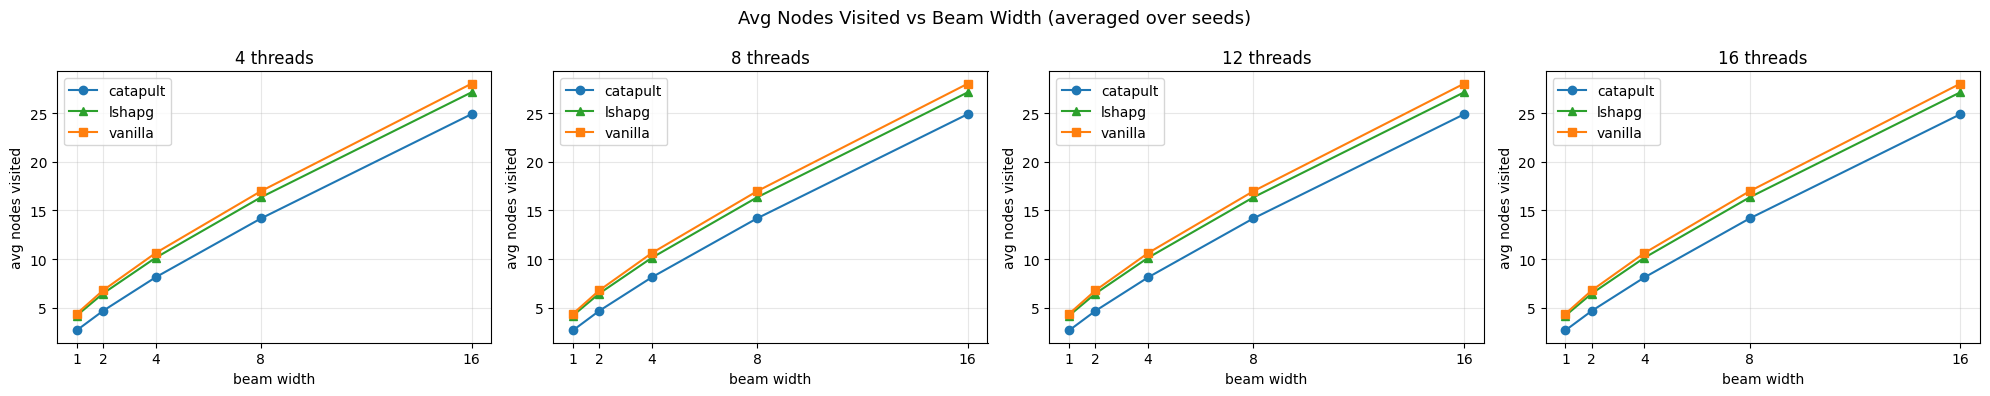

In [6]:
# Plot 3b: avg_nodes_visited vs beam_width per num_threads
csv = agg[['label', 'num_threads', 'beam_width', 'avg_nodes_visited']]
csv.to_csv('figures/uniform/plot3b_avg_nodes.csv', index=False)

fig, axes = plt.subplots(1, len(threads), figsize=(5 * len(threads), 4), sharey=False)
for ax, t in zip(axes, threads):
    for lbl in labels:
        sub = agg[(agg['label'] == lbl) & (agg['num_threads'] == t)].sort_values('beam_width')
        ax.plot(sub['beam_width'], sub['avg_nodes_visited'], marker=markers[lbl], color=colors[lbl], label=lbl)
    ax.set_title(f'{t} threads')
    ax.set_xlabel('beam width')
    ax.set_ylabel('avg nodes visited')
    ax.set_xticks(beam_widths)
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle('Avg Nodes Visited vs Beam Width (averaged over seeds)', fontsize=13)
plt.tight_layout()
fig.savefig('figures/uniform/plot3b_avg_nodes.png', dpi=150)
plt.show()

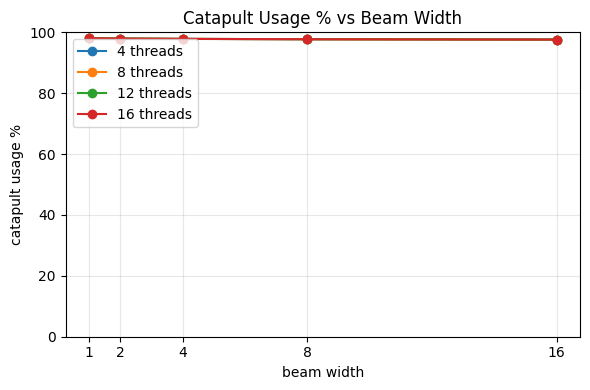

In [7]:
# Plot 4: catapult usage % vs beam_width
cat = agg[agg['label'] == 'catapult'][['num_threads', 'beam_width', 'catapult_usage_pct']]
cat.to_csv('figures/uniform/plot4_catapult_usage.csv', index=False)

fig, ax = plt.subplots(figsize=(6, 4))
for t in threads:
    sub = cat[cat['num_threads'] == t].sort_values('beam_width')
    ax.plot(sub['beam_width'], sub['catapult_usage_pct'], marker='o', label=f'{t} threads')
ax.set_xlabel('beam width')
ax.set_ylabel('catapult usage %')
ax.set_xticks(beam_widths)
ax.set_ylim(0, 100)
ax.set_title('Catapult Usage % vs Beam Width')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('figures/uniform/plot4_catapult_usage.png', dpi=150)
plt.show()

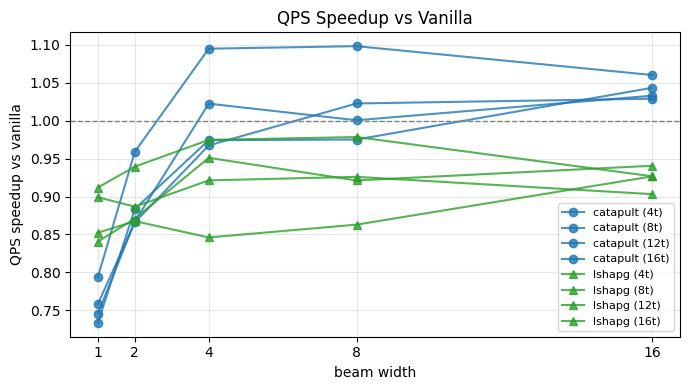

In [8]:
# Plot 5: QPS speedup ratio vs vanilla per beam_width per num_threads
van_df = agg[agg['label'] == 'vanilla'].set_index(['num_threads', 'beam_width'])['qps']
non_vanilla = [lbl for lbl in labels if lbl != 'vanilla']

speedup_rows = []
for lbl in non_vanilla:
    for t in threads:
        sub = agg[(agg['label'] == lbl) & (agg['num_threads'] == t)].sort_values('beam_width')
        speedup = sub.set_index('beam_width')['qps'] / van_df.xs(t, level='num_threads')
        for bw, s in speedup.items():
            speedup_rows.append({'label': lbl, 'num_threads': t, 'beam_width': bw, 'speedup': s})

speedup_df = pd.DataFrame(speedup_rows)
speedup_df.to_csv('figures/uniform/plot5_qps_speedup.csv', index=False)

fig, ax = plt.subplots(figsize=(7, 4))
for lbl in non_vanilla:
    for t in threads:
        sub = speedup_df[(speedup_df['label'] == lbl) & (speedup_df['num_threads'] == t)].sort_values('beam_width')
        ax.plot(sub['beam_width'], sub['speedup'], marker=markers[lbl], color=colors[lbl],
                label=f'{lbl} ({t}t)', alpha=0.8)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('beam width')
ax.set_ylabel('QPS speedup vs vanilla')
ax.set_xticks(beam_widths)
ax.set_title('QPS Speedup vs Vanilla')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('figures/uniform/plot5_qps_speedup.png', dpi=150)
plt.show()

In [9]:
def recall(a, b):
    return len(set(a) & set(b)) / len(set(a))

ground_truth_path = 'results/uniform_vanilla_ground_truth.json'
with open(ground_truth_path) as f:
    ground_truth = json.load(f)['results'][0]['neighbors']

recall_rows = []
for path in glob.glob('results/uniform_*_neighbors.json'):
    mode = re.search(r'uniform_(.+)_neighbors\.json', path).group(1)
    with open(path) as f:
        results = json.load(f)['results']
    for r in results:
        avg_recall = sum(
            recall(ground_truth[i][:len(q)], q)
            for i, q in enumerate(r['neighbors'])
        ) / len(r['neighbors'])
        recall_rows.append({
            'mode':        mode,
            'seed':        r['seed'],
            'num_threads': r['num_threads'],
            'beam_width':  r['beam_width'],
            'avg_recall':  avg_recall,
        })

recall_df = pd.DataFrame(recall_rows)
recall_df

,mode,seed,num_threads,beam_width,avg_recall
0,catapult,42,4,1,0.024860
1,catapult,42,4,2,0.051847
2,catapult,42,4,4,0.101088
3,catapult,42,4,8,0.182956
4,catapult,42,4,16,0.308071
...,...,...,...,...,...
175,lshapg,44,16,1,0.000000
176,lshapg,44,16,2,0.000030
177,lshapg,44,16,4,0.000028
178,lshapg,44,16,8,0.000058


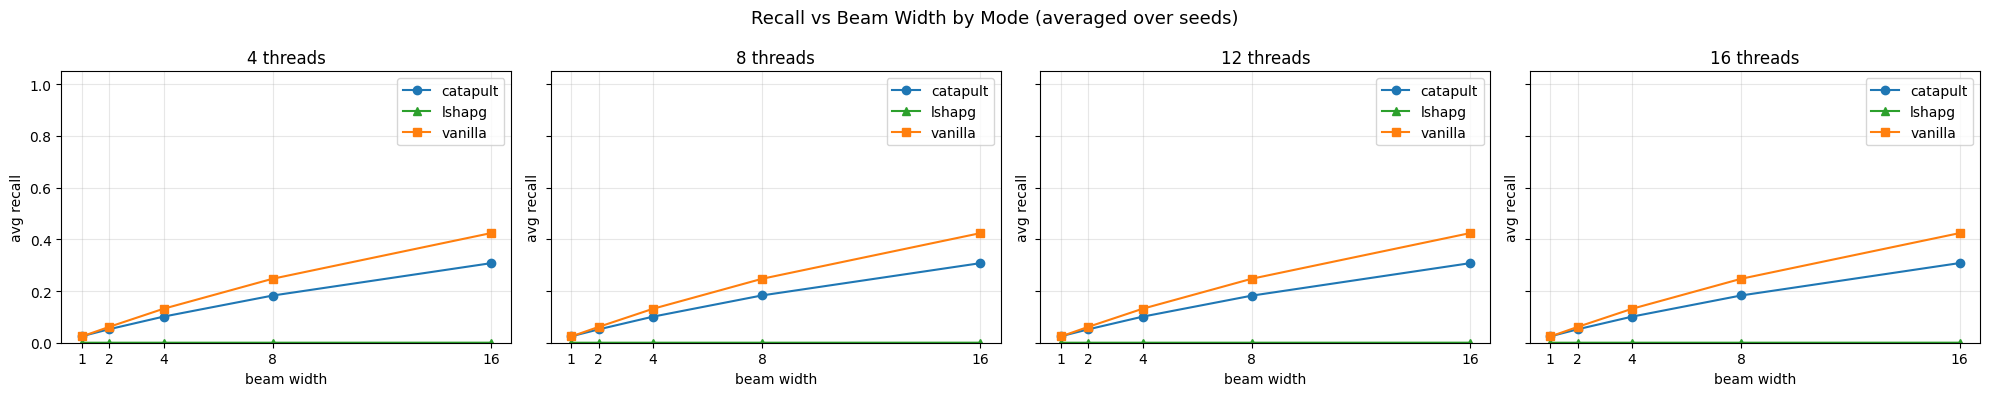

In [10]:
# Plot 6: Recall vs beam_width by mode, one subplot per num_threads (averaged over seeds)
recall_agg = recall_df.groupby(['mode', 'num_threads', 'beam_width'])['avg_recall'].mean().reset_index()
recall_agg.to_csv('figures/uniform/plot6_recall.csv', index=False)

recall_threads = sorted(recall_agg['num_threads'].unique())
fig, axes = plt.subplots(1, len(recall_threads), figsize=(5 * len(recall_threads), 4), sharey=True)
for ax, t in zip(axes, recall_threads):
    for mode in sorted(recall_agg['mode'].unique()):
        sub = recall_agg[(recall_agg['mode'] == mode) & (recall_agg['num_threads'] == t)].sort_values('beam_width')
        ax.plot(sub['beam_width'], sub['avg_recall'],
                marker=markers.get(mode, 'o'), color=colors.get(mode), label=mode)
    ax.set_title(f'{t} threads')
    ax.set_xlabel('beam width')
    ax.set_ylabel('avg recall')
    ax.set_xticks(sorted(recall_agg['beam_width'].unique()))
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle('Recall vs Beam Width by Mode (averaged over seeds)', fontsize=13)
plt.tight_layout()
fig.savefig('figures/uniform/plot6_recall.png', dpi=150)
plt.show()

In [11]:
# Relative % difference vs vanilla per beam_width, averaged over all threads (and seeds for recall)

perf_avg = agg.groupby(['label', 'beam_width']).agg(
    qps=('qps', 'mean'),
    avg_dists_computed=('avg_dists_computed', 'mean'),
    avg_nodes_visited=('avg_nodes_visited', 'mean'),
    catapult_usage_pct=('catapult_usage_pct', 'mean'),
).reset_index()

recall_avg = recall_df.groupby(['mode', 'beam_width'])['avg_recall'].mean().reset_index()
recall_avg.columns = ['label', 'beam_width', 'avg_recall']

combined = perf_avg.merge(recall_avg, on=['label', 'beam_width'], how='left')

vanilla = combined[combined['label'] == 'vanilla'].set_index('beam_width')
metrics = ['qps', 'avg_dists_computed', 'avg_nodes_visited', 'avg_recall']

rows = []
for lbl in sorted(combined['label'].unique()):
    if lbl == 'vanilla':
        continue
    sub = combined[combined['label'] == lbl].set_index('beam_width')
    for bw in sorted(sub.index):
        row = {'label': lbl, 'beam_width': bw, 'catapult_usage_pct': sub.loc[bw, 'catapult_usage_pct']}
        for m in metrics:
            v = vanilla.loc[bw, m] if bw in vanilla.index else float('nan')
            s = sub.loc[bw, m]
            row[f'{m}_rel_pct'] = (s - v) / abs(v) * 100 if (not pd.isna(v) and not pd.isna(s) and v != 0) else float('nan')
        rows.append(row)

rel_df = pd.DataFrame(rows)
rel_df.to_csv('figures/uniform/rel_pct_diff.csv', index=False)
display(rel_df.round(2))

# Per num_threads breakdown
recall_pt = recall_df.groupby(['mode', 'num_threads', 'beam_width'])['avg_recall'].mean().reset_index()
recall_pt.columns = ['label', 'num_threads', 'beam_width', 'avg_recall']

combined_pt = agg.merge(recall_pt, on=['label', 'num_threads', 'beam_width'], how='left')
vanilla_pt = combined_pt[combined_pt['label'] == 'vanilla'].set_index(['num_threads', 'beam_width'])

rows_pt = []
for lbl in sorted(combined_pt['label'].unique()):
    if lbl == 'vanilla':
        continue
    sub = combined_pt[combined_pt['label'] == lbl].set_index(['num_threads', 'beam_width'])
    for idx in sorted(sub.index):
        t, bw = idx
        row = {'label': lbl, 'num_threads': t, 'beam_width': bw, 'catapult_usage_pct': sub.loc[idx, 'catapult_usage_pct']}
        for m in metrics:
            v = vanilla_pt.loc[idx, m] if idx in vanilla_pt.index else float('nan')
            s = sub.loc[idx, m]
            row[f'{m}_rel_pct'] = (s - v) / abs(v) * 100 if (not pd.isna(v) and not pd.isna(s) and v != 0) else float('nan')
        rows_pt.append(row)

rel_df_pt = pd.DataFrame(rows_pt)
rel_df_pt.to_csv('figures/uniform/rel_pct_diff_per_thread.csv', index=False)
rel_df_pt.round(2)

,label,beam_width,catapult_usage_pct,qps_rel_pct,avg_dists_computed_rel_pct,avg_nodes_visited_rel_pct,avg_recall_rel_pct
0,catapult,1,98.12,-23.90,-12.83,-38.96,2.64
1,catapult,2,97.95,-9.69,-14.30,-31.01,-15.22
2,catapult,4,97.85,1.88,-13.03,-23.51,-23.18
3,catapult,8,97.74,3.07,-10.05,-16.48,-26.20
4,catapult,16,97.62,4.48,-7.39,-11.20,-27.40
5,lshapg,1,NaN,-11.84,-3.07,-4.30,-99.99
6,lshapg,2,NaN,-10.34,-2.55,-4.73,-99.97
7,lshapg,4,NaN,-8.12,-1.12,-4.59,-99.98
8,lshapg,8,NaN,-7.65,1.33,-3.71,-99.97
9,lshapg,16,NaN,-7.70,3.65,-3.18,-99.97


,label,num_threads,beam_width,catapult_usage_pct,qps_rel_pct,avg_dists_computed_rel_pct,avg_nodes_visited_rel_pct,avg_recall_rel_pct
0,catapult,4,1,98.12,-25.45,-12.83,-38.94,3.35
1,catapult,4,2,97.97,-13.28,-14.34,-31.04,-14.69
2,catapult,4,4,97.85,2.24,-12.99,-23.48,-23.14
3,catapult,4,8,97.74,0.05,-10.09,-16.53,-26.26
4,catapult,4,16,97.64,3.29,-7.36,-11.18,-27.44
5,catapult,8,1,98.14,-24.17,-12.86,-38.98,2.48
6,catapult,8,2,97.96,-13.40,-14.27,-31.00,-15.66
7,catapult,8,4,97.86,-3.27,-12.97,-23.45,-23.17
8,catapult,8,8,97.73,2.26,-10.01,-16.43,-26.02
9,catapult,8,16,97.60,2.89,-7.35,-11.17,-27.39
